
# Cây Quyết Định & Rừng Ngẫu Nhiên – Dự báo giá nhà (Ames Housing, Kaggle)

**Mục tiêu:** Sinh viên nắm được quy trình từ tiền xử lý, xây dựng mô hình Cây quyết định & Rừng ngẫu nhiên, đánh giá (RMSE/MAE/R²), tinh chỉnh siêu tham số, diễn giải bằng Permutation Importance, và tạo `submission.csv` cho Kaggle.

**Bộ dữ liệu:** *Housing Prices: Home Data for ML Course* (Ames). Cột mục tiêu `SalePrice`.



## Bước 0 — Cài đặt & import thư viện

- Import các thư viện cần thiết cho tiền xử lý, mô hình, đánh giá.
- Thiết lập `random_state` để tái lập kết quả.


In [1]:

# Lời giải 0
import os
from pathlib import Path
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
DATA_DIR = Path('./Data/CSV/HomeData')  # Đặt train.csv, test.csv tại đây
DATA_DIR.mkdir(exist_ok=True)

def rmse(y_true, y_pred):
    return root_mean_squared_error(y_true, y_pred, squared=False)

print('Thư viện đã sẵn sàng. Thư mục dữ liệu:', DATA_DIR.resolve())


Thư viện đã sẵn sàng. Thư mục dữ liệu: E:\.Data\Documents\Code\4. Python\AI_Introduct\Data\CSV\HomeData



## Bước 1 — Chuẩn bị & đọc dữ liệu

1. Tải dữ liệu từ Kaggle: cuộc thi **Home Data for ML Course**: https://www.kaggle.com/competitions/home-data-for-ml-course/data
 và đặt `train.csv`, `test.csv` vào thư mục `./home-data/`.
2. Đọc `train.csv`, kiểm tra kích thước, liệt kê một vài cột.
3. Xác định cột mục tiêu `SalePrice` và tách `X`, `y`.


In [2]:

# Lời giải 1
train_fp = DATA_DIR / 'train.csv'
test_fp  = DATA_DIR / 'test.csv'

if not train_fp.exists():
    print(f'⚠️ Không tìm thấy {train_fp}. Hãy tải từ Kaggle và đặt các file vào {DATA_DIR.resolve()}')
else:
    train_df = pd.read_csv(train_fp)
    print('Kích thước train:', train_df.shape)
    print('Các cột:', list(train_df.columns[:10]), '...')
    display_cols = [c for c in train_df.columns if c not in ['SalePrice']][:8] + ['SalePrice']

    display(train_df[display_cols].head(12))

    y = train_df['SalePrice']
    X = train_df.drop(columns=['SalePrice', 'Id'], errors='ignore')

    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    print(f'Số đặc trưng: số={len(num_cols)}, phân loại={len(cat_cols)}')


Kích thước train: (1460, 81)
Các cột: ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities'] ...


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,118000


Số đặc trưng: số=36, phân loại=43



## Bước 2 — Xây dựng pipeline tiền xử lý

- Với biến số: điền khuyết bằng **median**.
- Với biến phân loại: điền khuyết **mode** và **One-Hot Encoding** (bỏ qua nhãn lạ).
- Kết hợp bằng `ColumnTransformer`.


In [3]:
# Lời giải 2 (bản đã sửa, tương thích sklearn mới/cũ)
if 'X' in globals():
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ])

    # Tương thích: sklearn >=1.2 dùng 'sparse_output', sklearn cũ dùng 'sparse'
    ohe_kwargs = dict(handle_unknown='ignore')
    try:
        # sklearn mới (>=1.2, đặc biệt >=1.4)
        ohe = OneHotEncoder(sparse_output=False, **ohe_kwargs)
    except TypeError:
        # sklearn cũ (<1.2)
        ohe = OneHotEncoder(sparse=False, **ohe_kwargs)
    #Pipeline cho cột số: điền khuyết bằng median
    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', ohe)
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ('num', numeric_pipe, num_cols),
            ('cat', categorical_pipe, cat_cols),
        ],
        remainder='drop'
    )
    print('Đã tạo pipeline tiền xử lý.')
else:
    print('⚠️ Chưa có X,y. Hãy chạy ô trên để đọc dữ liệu.')


Đã tạo pipeline tiền xử lý.



## Đề bài 3 — Baseline: Decision Tree với K-fold CV

- Xây dựng `Pipeline(preprocess → DecisionTreeRegressor)`.
- Đánh giá bằng 5-fold CV với các chỉ số **RMSE**, **MAE**, **R²**.


In [4]:

# Lời giải 3
if 'X' in globals():
    dt_pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))
    ])
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = {
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    }
    dt_cv = cross_validate(dt_pipe, X, y, scoring=scoring, cv=cv, n_jobs=-1)
    dt_rmse = -dt_cv['test_rmse'].mean()
    dt_mae  = -dt_cv['test_mae'].mean()
    dt_r2   =  dt_cv['test_r2'].mean()
    print(f'[DecisionTree] 5-fold CV → RMSE={dt_rmse:,.0f} | MAE={dt_mae:,.0f} | R²={dt_r2:.3f}')
else:
    print('⚠️ Chưa có X,y.')


[DecisionTree] 5-fold CV → RMSE=45,552 | MAE=27,692 | R²=0.658



## Đề bài 4 — Baseline: Random Forest với K-fold CV

- Xây dựng `Pipeline(preprocess → RandomForestRegressor(n_estimators=500))`.
- So sánh điểm số với Decision Tree.


In [5]:

# Lời giải 4
if 'X' in globals():
    rf_pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', RandomForestRegressor(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1))
    ])
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = {
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    }
    rf_cv = cross_validate(rf_pipe, X, y, scoring=scoring, cv=cv, n_jobs=-1)
    rf_rmse = -rf_cv['test_rmse'].mean()
    rf_mae  = -rf_cv['test_mae'].mean()
    rf_r2   =  rf_cv['test_r2'].mean()
    print(f'[RandomForest] 5-fold CV → RMSE={rf_rmse:,.0f} | MAE={rf_mae:,.0f} | R²={rf_r2:.3f}')
else:
    print('⚠️ Chưa có X,y.')


[RandomForest] 5-fold CV → RMSE=30,228 | MAE=17,737 | R²=0.840



## Đề bài 5 — Tinh chỉnh siêu tham số

- **Decision Tree**: dùng `GridSearchCV` trên `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`.
- **Random Forest**: dùng `RandomizedSearchCV` (ít nhất 20 tổ hợp) trên `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, `bootstrap`.
- Chọn mô hình có **CV RMSE** tốt nhất.


In [6]:

# Lời giải 5
if 'X' in globals():
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    # Decision Tree – Grid
    dt_pipe = Pipeline([('preprocess', preprocess),
                        ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))])
    dt_grid = {
        'model__max_depth': [None, 10, 20, 30, 40],
        'model__min_samples_split': [2, 10, 50],
        'model__min_samples_leaf': [1, 5, 20],
        'model__max_features': [None, 'sqrt', 0.5]
    }
    dt_gs = GridSearchCV(dt_pipe, dt_grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1)
    dt_gs.fit(X, y)
    dt_best_rmse = -dt_gs.best_score_
    print('Best DT params:', dt_gs.best_params_)
    print('Best DT CV RMSE:', f'{dt_best_rmse:,.0f}')

    # Random Forest – Randomized
    rf_pipe = Pipeline([('preprocess', preprocess),
                        ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))])
    rf_param_space = {
        'model__n_estimators': [300, 400, 500, 600, 800, 1000],
        'model__max_depth': [None, 10, 20, 30, 40, 50],
        'model__min_samples_split': [2, 5, 10, 20],
        'model__min_samples_leaf': [1, 2, 5, 10],
        'model__max_features': ['sqrt', 0.5, 0.75, None],
        'model__bootstrap': [True, False],
    }
    rf_rs = RandomizedSearchCV(
        rf_pipe, rf_param_space, n_iter=25, scoring='neg_root_mean_squared_error',
        cv=cv, n_jobs=-1, random_state=RANDOM_STATE, verbose=0
    )
    rf_rs.fit(X, y)
    rf_best_rmse = -rf_rs.best_score_
    print('Best RF params:', rf_rs.best_params_)
    print('Best RF CV RMSE:', f'{rf_best_rmse:,.0f}')

    best_pipe = rf_rs.best_estimator_ if rf_best_rmse < dt_best_rmse else dt_gs.best_estimator_
    print('=> Chọn mô hình tốt nhất:', type(best_pipe.named_steps['model']).__name__)
else:
    print('⚠️ Chưa có X,y.')


Best DT params: {'model__max_depth': None, 'model__max_features': None, 'model__min_samples_leaf': 20, 'model__min_samples_split': 2}
Best DT CV RMSE: 38,018
Best RF params: {'model__n_estimators': 800, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None, 'model__bootstrap': True}
Best RF CV RMSE: 29,130
=> Chọn mô hình tốt nhất: RandomForestRegressor



## Đề bài 6 — Đánh giá hold-out & Permutation Importance

- Chia `train/validation` (ví dụ 80/20).
- Huấn luyện mô hình tốt nhất, báo cáo **RMSE/MAE/R²** trên validation.
- Tính **Permutation Importance**, in **Top-25** đặc trưng quan trọng và **vẽ biểu đồ cột ngang**.


[Hold-out] RMSE=28,617 | MAE=16,954 | R²=0.893

Top 25 features (Permutation Importance – tăng RMSE khi xáo trộn):
num__BsmtFullBath                              23784.467688
cat__LotShape_IR1                              12534.152593
cat__LandSlope_Gtl                             5098.747626
cat__MSZoning_FV                               3127.995730
cat__Alley_Grvl                                2683.109421
cat__Street_Pave                               2531.904646
num__MiscVal                                   1904.203161
num__FullBath                                  1596.999634
num__OverallQual                               1384.513085
num__GarageArea                                1345.369131
num__EnclosedPorch                             1165.520587
cat__LandSlope_Mod                             1073.927349
cat__LandContour_Lvl                           786.903911
cat__LotShape_Reg                              579.253331
cat__Utilities_AllPub                          570.092908
c

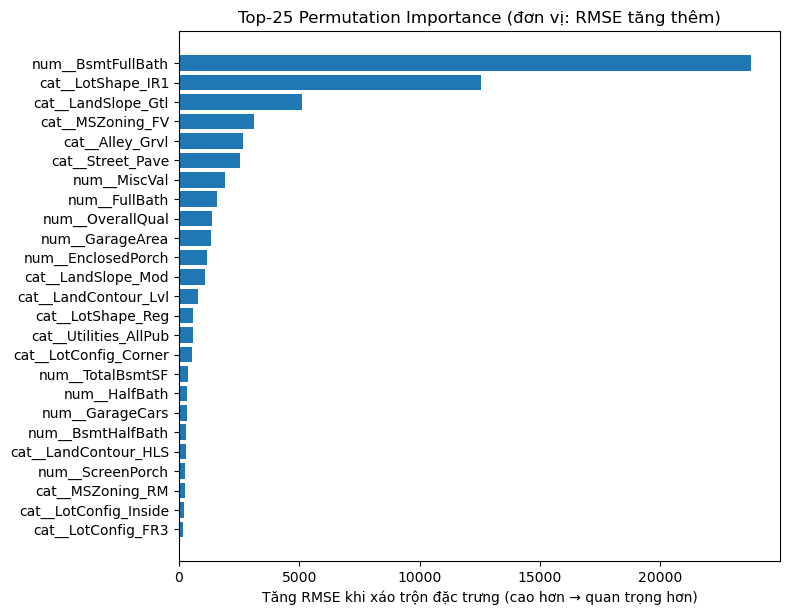

In [7]:
# Lời giải 6 (bản đã sửa: nhãn & tính permutation importance đúng nghĩa)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

# Phòng khi chưa có hằng số seed
if 'RANDOM_STATE' not in globals():
    RANDOM_STATE = 42

if 'X' in globals() and 'y' in globals() and 'best_pipe' in globals():
    # Tách hold-out 20%
    X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

    # Fit mô hình tốt nhất trên tập train và đánh giá trên validation
    best_pipe.fit(X_tr, y_tr)
    va_pred = best_pipe.predict(X_va)

    rmse_val = float(np.sqrt(mean_squared_error(y_va, va_pred)))
    mae_val  = float(mean_absolute_error(y_va, va_pred))
    r2_val   = float(r2_score(y_va, va_pred))
    print(f'[Hold-out] RMSE={rmse_val:,.0f} | MAE={mae_val:,.0f} | R²={r2_val:.3f}')

    # Permutation Importance:
    # với scoring='neg_root_mean_squared_error', importances_mean = RMSE_perm - RMSE_base
    # => giá trị càng lớn -> quan trọng hơn (vì làm RMSE tăng nhiều khi xáo trộn)
    perm = permutation_importance(
        best_pipe, X_va, y_va,
        scoring='neg_root_mean_squared_error',
        n_repeats=7, random_state=RANDOM_STATE, n_jobs=-1
    )

    # Lấy tên cột sau biến đổi
    feat_names = best_pipe.named_steps['preprocess'].get_feature_names_out()
    imp_rmse = perm.importances_mean  # đơn vị: "tăng RMSE" khi xáo trộn
    order = np.argsort(-imp_rmse)
    topk = 25
    top_idx = order[:topk]

    # In Top-25
    print('\nTop 25 features (Permutation Importance – tăng RMSE khi xáo trộn):')
    for i in top_idx:
        print(f'{feat_names[i]:45s}  {imp_rmse[i]:.6f}')

    # Biểu đồ thanh ngang
    plt.figure(figsize=(8, max(4, topk * 0.25)))
    plt.barh(range(topk), imp_rmse[top_idx][::-1])
    plt.yticks(range(topk), [feat_names[i] for i in top_idx][::-1])
    plt.xlabel('Tăng RMSE khi xáo trộn đặc trưng (cao hơn → quan trọng hơn)')
    plt.title('Top-25 Permutation Importance (đơn vị: RMSE tăng thêm)')
    plt.tight_layout()
    plt.show()

else:
    print('⚠️ Chưa có X, y, hoặc best_pipe. Hãy chạy các ô trước đó (tạo best_pipe) rồi thử lại.')



## Đề bài 7 — Huấn luyện full & tạo `submission.csv`

- Huấn luyện mô hình tốt nhất trên **toàn bộ train**.
- Dự đoán `SalePrice` cho `test.csv` và ghi `./HomeData/submission.csv`.
- (Tuỳ chọn) Nộp lên Kaggle để nhận điểm Public LB.


In [8]:

# Lời giải 7
if 'X' in globals():
    if not test_fp.exists():
        print(f'⚠️ Không tìm thấy {test_fp}. Bỏ qua bước submission.')
    else:
        test_df = pd.read_csv(test_fp)
        test_ids = test_df['Id'] if 'Id' in test_df.columns else pd.Series(np.arange(len(test_df)))
        X_test = test_df.drop(columns=['Id'], errors='ignore')

        best_pipe.fit(X, y)  # train full
        test_pred = best_pipe.predict(X_test)

        out_fp = DATA_DIR / 'submission.csv'
        pd.DataFrame({'Id': test_ids, 'SalePrice': test_pred}).to_csv(out_fp, index=False)
        print('✅ Đã ghi file submission:', out_fp.resolve())
else:
    print('⚠️ Chưa có X,y.')


✅ Đã ghi file submission: E:\.Data\Documents\Code\4. Python\AI_Introduct\Data\CSV\HomeData\submission.csv



---

## Bài tập tự luyện (giao cho sinh viên)

1. **Cây quyết định (Cơ bản):** chạy lưới `max_depth ∈ {5, 10, 20, None}`, `min_samples_leaf ∈ {1, 5, 20}` và báo cáo bảng 5-fold CV (RMSE/MAE/R²). Phân tích overfitting khi `max_depth=None`.
2. **Rừng ngẫu nhiên (Trung bình):** chạy `RandomizedSearchCV` ≥ 20 tổ hợp; so sánh RF baseline (500 cây) với RF tối ưu bằng biểu đồ RMSE.
3. **Lựa chọn đặc trưng (Trung bình):** tính Permutation Importance; loại 10 đặc trưng ít quan trọng nhất; huấn luyện lại và so sánh điểm số.
4. **Ổn định mô hình (Nâng cao):** lặp lại thí nghiệm với 3 giá trị `random_state` (0, 42, 2025); báo cáo trung bình ± độ lệch chuẩn.
5. **Kaggle (Ứng dụng):** tạo `submission.csv` và nộp; chụp ảnh/ghi điểm Public LB, thảo luận sai khác với CV.

> Gợi ý: khi chạy lâu, có thể giảm `n_iter` của RandomizedSearch hoặc giới hạn `max_depth`/`n_estimators` trong quá trình thử nghiệm.
